<a href="https://colab.research.google.com/github/Nguyen-T-C-Cac/TieuLuan_NghiencuuppcaithenchatluonganhtuDiffusionModels_colab/blob/main/SD_Real_ESRGAN_withdataset_MSCOCO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



> Bản gốc



# **Cài đặt môi trường**

In [ ]:
import logging
import warnings

# Tắt cảnh báo từ Diffusers và Transformers
logging.getLogger("diffusers").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")



> Thư viện Diffuser




In [ ]:
!pip install diffusers["torch"] transformers
!pip install accelerate



> Clone Real-ESRGAN **[Tài liệu hướng dẫn](https://colab.research.google.com/drive/1k2Zod6kSHEvraybHl50Lys0LerhyTMCo?usp=sharing#scrollTo=IRDbDYYMQt_Y)**



In [ ]:
!git clone https://github.com/xinntao/Real-ESRGAN.git
%cd Real-ESRGAN
# Set up the environment
!pip install basicsr
!pip install facexlib
!pip install gfpgan
!pip install -r requirements.txt
!python setup.py develop

Cloning into 'Real-ESRGAN'...
remote: Enumerating objects: 759, done.
remote: Total 759 (delta 0), reused 0 (delta 0), pack-reused 759 (from 1)
Receiving objects: 100% (759/759), 5.39 MiB | 38.03 MiB/s, done.
Resolving deltas: 100% (408/408), done.
/content/Real-ESRGAN
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 12.6 MB/s eta 0:00:00
  Created wheel for basicsr: filename=basicsr-1.4.2-py3-none-any.whl size=214817 sha256=a095cf56553bf57b97f35443acfe6f5835b9d1669a6a862922f454785fe92915
  Stored in directory: /root/.cache/pip/wheels/9a/e3/e4/58f29bfabb622dd40b6d9839318ce5bf092062b81ca3aa19ea
Successfully built basicsr
  

In [ ]:
# sửa lỗi đường dẫn import bên trong thư viện basicsr
!sed -i 's/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/' /usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py


> Thư viện đo CLIP Score, IS và FID

In [ ]:
!pip install torchmetrics[image]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.8 MB/s eta 0:00:00


# **Thư viện**

In [ ]:
from datasets import load_dataset
import os
import torch
import time
import pandas as pd
from PIL import Image
import numpy as np
from tqdm import tqdm
import torchvision.transforms as T
from diffusers import (
    StableDiffusionPipeline,
    DDIMScheduler,
    EulerDiscreteScheduler,
    DPMSolverMultistepScheduler
)
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

import matplotlib.pyplot as plt
import math
import seaborn as sns
import numpy as np

# cấu hình đường dẫn
from google.colab import drive
drive.mount('/content/gdrive/')
%cd '/content/gdrive/MyDrive/TLTN'
output_dir = "/content/gdrive/MyDrive/TLTN/img_gen/ddim_img"

dataset = load_dataset("Cakz05/COCO_test5k", split="test")
print(f"Đã load từ dataset {len(dataset)} dòng.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Mounted at /content/gdrive/
/content/gdrive/MyDrive/TLTN


README.md:   0%|          | 0.00/527 [00:00<?, ?B/s]

data/test-00000-of-00002.parquet:   0%|          | 0.00/410M [00:00<?, ?B/s]

data/test-00001-of-00002.parquet:   0%|          | 0.00/412M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Đã load từ dataset 5000 dòng.


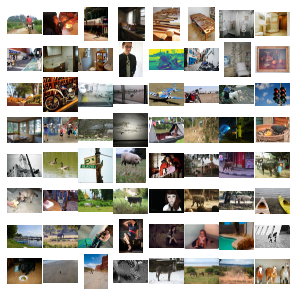

In [ ]:
# Vẽ hình ảnh dataset với 64 ảnh
def drawpic(dataset, total_img=64, col=8):
    # Tính số hàng dựa trên tổng số ảnh và số cột
    row = math.ceil(total_img / col)

    fig, axes = plt.subplots(row,
        col,
        figsize=(col * 0.5, row * 0.5),
        dpi=72,
        gridspec_kw={"wspace": 0.02, "hspace": 0.02},
      )
    axes = axes.flatten()

    for i in range(total_img):
        if i < len(dataset):
            # Lấy dữ liệu ảnh từ cột 'image'
            img = dataset[i]['image']
            axes[i].imshow(img)

            # caption
            ''' if 'filename' in dataset[i]:
                file_name = dataset[i]['filename']
                axes[i].set_title(file_name, fontsize=6, pad=1)
            '''
        # Ẩn các trục tọa độ x, y
        axes[i].axis('off')

    # Tối ưu khoảng cách giữa các ô ảnh không bị đè lên nhau
    plt.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.99)
    plt.show()

# Gọi hàm hiển thị lưới 64 ảnh (Ma trận 8x8)
drawpic(dataset, total_img=64, col=8)

# **Cấu hình Stable Diffusion và các Sampler**

In [ ]:
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5",
                                                torch_dtype=torch.float16,
                                                safety_checker=None,  # Tắt checker để nhanh hơn
                                                requires_safety_checker=False)
neg_prompt = "nsfw, nude, naked, ugly, deformed, blurry, bad anatomy, bad proportions, disfigured, poorly drawn face, poorly drawn hands, extra limbs, worst quality, low quality"
pipe = pipe.to("cuda")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


AssertionError: Torch not compiled with CUDA enabled



> Danh sách các cấu hình



In [ ]:
configs = [
    {"name": "DDIM_30", "scheduler": DDIMScheduler.from_config(pipe.scheduler.config), "steps": 30},
    {"name": "Euler_20", "scheduler": EulerDiscreteScheduler.from_config(pipe.scheduler.config), "steps": 20},
    # Bật use_karras_sigmas=True để kích hoạt Karras
    {"name": "DPM2MKarras_15", "scheduler": DPMSolverMultistepScheduler.from_config(pipe.scheduler.config, use_karras_sigmas=True), "steps": 15}
]



> Khởi tạo Real-ESRGAN



In [ ]:
model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=4)
upsampler = RealESRGANer(
    scale=4,
    model_path='https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth',
    model=model,
    tile=400, # Tránh tràn VRAM trên Colab
    tile_pad=10,
    pre_pad=0,
    half=True # Sử dụng float16 để tối ưu bộ nhớ
)

Downloading: "https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth" to /content/Real-ESRGAN/weights/RealESRGAN_x4plus.pth



100%|██████████| 63.9M/63.9M [00:00<00:00, 225MB/s]


# **Tạo ảnh chuẩn DDIM 100 bước**

In [ ]:
base_dir = "/content/gdrive/MyDrive/TLTN"
log_baseline_path = os.path.join(base_dir, "metrics_DDIM_100.csv")
#khởi tạo file ghi log
done_ids = set()

if os.path.exists(log_baseline_path):
    print(f"Tìm thấy file log cũ: {log_baseline_path}")
    df_old = pd.read_csv(log_baseline_path)
    done_ids = set(df_old['idx'].tolist())
else:
    # tạo file + header
    with open(log_baseline_path, "w") as f:
        f.write("idx,sd_time,gpu_mem_mb\n")

print(f"Resume được {len(done_ids)} ảnh")

# lặp sinh ảnh
for i, item in tqdm(enumerate(dataset), total=len(dataset)):

    # skip nếu đã xử lý rồi
    if i in done_ids:
        continue

    prompt = item['sentences'][0]
    save_path = os.path.join(output_dir, f"img_{i:05d}.png")

    # skip nếu ảnh đã tồn tại (optional)
    if os.path.exists(save_path):
        print(f"Skip ảnh {i} (đã tồn tại)")
        continue

    generator = torch.Generator(device="cuda").manual_seed(42 + i)

    try:
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
        start_time = time.time()

        image = pipe(
            prompt=prompt,
            negative_prompt=neg_prompt,
            num_inference_steps=100,
            guidance_scale=7.5,
            generator=generator
        ).images[0]

        torch.cuda.synchronize()
        sd_time = time.time() - start_time
        max_mem = torch.cuda.max_memory_allocated() / 1024**2

        # lưu ảnh
        image.save(save_path)

        # ghi log ngay
        with open(log_baseline_path, "a") as f:
            f.write(f"{i},{sd_time:.4f},{max_mem:.2f}\n")

    except Exception as e:
        print(f"Lỗi tại ảnh {i}: {e}")
        continue

print("Đã hoàn thành sinh ảnh với DDIM 100 steps.")

Tìm thấy file log cũ: /content/gdrive/MyDrive/TLTN/metrics_DDIM_100.csv
Resume được 0 ảnh


  1%|          | 26/5000 [00:14<32:38,  2.54it/s]  

Skip ảnh 0 (đã tồn tại)
Skip ảnh 1 (đã tồn tại)
Skip ảnh 2 (đã tồn tại)
Skip ảnh 3 (đã tồn tại)
Skip ảnh 4 (đã tồn tại)
Skip ảnh 5 (đã tồn tại)
Skip ảnh 6 (đã tồn tại)
Skip ảnh 7 (đã tồn tại)
Skip ảnh 8 (đã tồn tại)
Skip ảnh 9 (đã tồn tại)
Skip ảnh 10 (đã tồn tại)
Skip ảnh 11 (đã tồn tại)
Skip ảnh 12 (đã tồn tại)
Skip ảnh 13 (đã tồn tại)
Skip ảnh 14 (đã tồn tại)
Skip ảnh 15 (đã tồn tại)
Skip ảnh 16 (đã tồn tại)
Skip ảnh 17 (đã tồn tại)
Skip ảnh 18 (đã tồn tại)
Skip ảnh 19 (đã tồn tại)
Skip ảnh 20 (đã tồn tại)
Skip ảnh 21 (đã tồn tại)
Skip ảnh 22 (đã tồn tại)
Skip ảnh 23 (đã tồn tại)
Skip ảnh 24 (đã tồn tại)
Skip ảnh 25 (đã tồn tại)
Skip ảnh 26 (đã tồn tại)
Skip ảnh 27 (đã tồn tại)
Skip ảnh 28 (đã tồn tại)
Skip ảnh 29 (đã tồn tại)
Skip ảnh 30 (đã tồn tại)
Skip ảnh 31 (đã tồn tại)
Skip ảnh 32 (đã tồn tại)
Skip ảnh 33 (đã tồn tại)
Skip ảnh 34 (đã tồn tại)
Skip ảnh 35 (đã tồn tại)
Skip ảnh 36 (đã tồn tại)
Skip ảnh 37 (đã tồn tại)
Skip ảnh 38 (đã tồn tại)
Skip ảnh 39 (đã tồn tại)
Skip ảnh 4

  2%|▏         | 75/5000 [00:14<07:46, 10.56it/s]

Skip ảnh 43 (đã tồn tại)
Skip ảnh 44 (đã tồn tại)
Skip ảnh 45 (đã tồn tại)
Skip ảnh 46 (đã tồn tại)
Skip ảnh 47 (đã tồn tại)
Skip ảnh 48 (đã tồn tại)
Skip ảnh 49 (đã tồn tại)
Skip ảnh 50 (đã tồn tại)
Skip ảnh 51 (đã tồn tại)
Skip ảnh 52 (đã tồn tại)
Skip ảnh 53 (đã tồn tại)
Skip ảnh 54 (đã tồn tại)
Skip ảnh 55 (đã tồn tại)
Skip ảnh 56 (đã tồn tại)
Skip ảnh 57 (đã tồn tại)
Skip ảnh 58 (đã tồn tại)
Skip ảnh 59 (đã tồn tại)
Skip ảnh 60 (đã tồn tại)
Skip ảnh 61 (đã tồn tại)
Skip ảnh 62 (đã tồn tại)
Skip ảnh 63 (đã tồn tại)
Skip ảnh 64 (đã tồn tại)
Skip ảnh 65 (đã tồn tại)
Skip ảnh 66 (đã tồn tại)
Skip ảnh 67 (đã tồn tại)
Skip ảnh 68 (đã tồn tại)
Skip ảnh 69 (đã tồn tại)
Skip ảnh 70 (đã tồn tại)
Skip ảnh 71 (đã tồn tại)
Skip ảnh 72 (đã tồn tại)
Skip ảnh 73 (đã tồn tại)
Skip ảnh 74 (đã tồn tại)
Skip ảnh 75 (đã tồn tại)
Skip ảnh 76 (đã tồn tại)
Skip ảnh 77 (đã tồn tại)
Skip ảnh 78 (đã tồn tại)
Skip ảnh 79 (đã tồn tại)
Skip ảnh 80 (đã tồn tại)
Skip ảnh 81 (đã tồn tại)
Skip ảnh 82 (đã tồn tại)


...

Skip ảnh 4909 (đã tồn tại)
Skip ảnh 4910 (đã tồn tại)
Skip ảnh 4911 (đã tồn tại)
Skip ảnh 4912 (đã tồn tại)
Skip ảnh 4913 (đã tồn tại)
Skip ảnh 4914 (đã tồn tại)
Skip ảnh 4915 (đã tồn tại)
Skip ảnh 4916 (đã tồn tại)
Skip ảnh 4917 (đã tồn tại)
Skip ảnh 4918 (đã tồn tại)
Skip ảnh 4919 (đã tồn tại)
Skip ảnh 4920 (đã tồn tại)
Skip ảnh 4921 (đã tồn tại)
Skip ảnh 4922 (đã tồn tại)
Skip ảnh 4923 (đã tồn tại)
Skip ảnh 4924 (đã tồn tại)
Skip ảnh 4925 (đã tồn tại)
Skip ảnh 4926 (đã tồn tại)
Skip ảnh 4927 (đã tồn tại)
Skip ảnh 4928 (đã tồn tại)
Skip ảnh 4929 (đã tồn tại)
Skip ảnh 4930 (đã tồn tại)
Skip ảnh 4931 (đã tồn tại)
Skip ảnh 4932 (đã tồn tại)
Skip ảnh 4933 (đã tồn tại)
Skip ảnh 4934 (đã tồn tại)
Skip ảnh 4935 (đã tồn tại)
Skip ảnh 4936 (đã tồn tại)
Skip ảnh 4937 (đã tồn tại)
Skip ảnh 4938 (đã tồn tại)
Skip ảnh 4939 (đã tồn tại)
Skip ảnh 4940 (đã tồn tại)
Skip ảnh 4941 (đã tồn tại)
Skip ảnh 4942 (đã tồn tại)
Skip ảnh 4943 (đã tồn tại)
Skip ảnh 4944 (đã tồn tại)
Skip ảnh 4945 (đã tồn tại)


100%|█████████▉| 4980/5000 [00:36<00:00, 174.43it/s]

Skip ảnh 4946 (đã tồn tại)
Skip ảnh 4947 (đã tồn tại)
Skip ảnh 4948 (đã tồn tại)
Skip ảnh 4949 (đã tồn tại)
Skip ảnh 4950 (đã tồn tại)
Skip ảnh 4951 (đã tồn tại)
Skip ảnh 4952 (đã tồn tại)
Skip ảnh 4953 (đã tồn tại)
Skip ảnh 4954 (đã tồn tại)
Skip ảnh 4955 (đã tồn tại)
Skip ảnh 4956 (đã tồn tại)
Skip ảnh 4957 (đã tồn tại)
Skip ảnh 4958 (đã tồn tại)
Skip ảnh 4959 (đã tồn tại)
Skip ảnh 4960 (đã tồn tại)
Skip ảnh 4961 (đã tồn tại)
Skip ảnh 4962 (đã tồn tại)
Skip ảnh 4963 (đã tồn tại)
Skip ảnh 4964 (đã tồn tại)
Skip ảnh 4965 (đã tồn tại)
Skip ảnh 4966 (đã tồn tại)
Skip ảnh 4967 (đã tồn tại)
Skip ảnh 4968 (đã tồn tại)
Skip ảnh 4969 (đã tồn tại)
Skip ảnh 4970 (đã tồn tại)
Skip ảnh 4971 (đã tồn tại)
Skip ảnh 4972 (đã tồn tại)
Skip ảnh 4973 (đã tồn tại)
Skip ảnh 4974 (đã tồn tại)
Skip ảnh 4975 (đã tồn tại)
Skip ảnh 4976 (đã tồn tại)
Skip ảnh 4977 (đã tồn tại)
Skip ảnh 4978 (đã tồn tại)
Skip ảnh 4979 (đã tồn tại)
Skip ảnh 4980 (đã tồn tại)


100%|██████████| 5000/5000 [00:36<00:00, 135.22it/s]

Skip ảnh 4981 (đã tồn tại)
Skip ảnh 4982 (đã tồn tại)
Skip ảnh 4983 (đã tồn tại)
Skip ảnh 4984 (đã tồn tại)
Skip ảnh 4985 (đã tồn tại)
Skip ảnh 4986 (đã tồn tại)
Skip ảnh 4987 (đã tồn tại)
Skip ảnh 4988 (đã tồn tại)
Skip ảnh 4989 (đã tồn tại)
Skip ảnh 4990 (đã tồn tại)
Skip ảnh 4991 (đã tồn tại)
Skip ảnh 4992 (đã tồn tại)
Skip ảnh 4993 (đã tồn tại)
Skip ảnh 4994 (đã tồn tại)
Skip ảnh 4995 (đã tồn tại)
Skip ảnh 4996 (đã tồn tại)
Skip ảnh 4997 (đã tồn tại)
Skip ảnh 4998 (đã tồn tại)
Skip ảnh 4999 (đã tồn tại)
Đã hoàn thành sinh ảnh với DDIM 100 steps.




> Đo Time & Memory cho DDIM 100 bước (Chỉ 100 ảnh)



In [ ]:
#100 ảnh mất 30p
print("Bắt đầu đo lường Time & Memory cho DDIM 100 steps (Mẫu 100 ảnh)...")
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

times = []
memories = []

# Chỉ lấy 105 ảnh đầu tiên (Bỏ 5 ảnh đầu làm Warm-up)
subset_dataset = dataset.select(range(105))

for i, item in enumerate(subset_dataset):
    prompt = item['sentences'][0]
    generator = torch.Generator(device="cuda").manual_seed(42 + i)

    torch.cuda.reset_peak_memory_stats()
    start_time = time.time()

    # Không cần lưu ảnh, chỉ cần chạy qua model để đo
    _ = pipe(
        prompt=prompt,
        negative_prompt=neg_prompt,
        num_inference_steps=100,
        guidance_scale=7.5,
        generator=generator,
        output_type="np" # Xuất numpy cho lẹ không cần render PIL
    ).images[0]

    infer_time = time.time() - start_time
    max_mem = torch.cuda.max_memory_allocated() / 1024**2

    # Bỏ qua 5 ảnh đầu tiên (Warm-up GPU)
    if i >= 5:
        times.append(infer_time)
        memories.append(max_mem)

# Tính toán kết quả
avg_time = np.mean(times)
std_time = np.std(times)
avg_mem = np.mean(memories)

print(f"* KẾT QUẢ ĐO LƯỜNG DDIM 100 BƯỚC (Trên 100 ảnh mẫu):")
print(f"- Thời gian TB/ảnh: {avg_time:.2f} giây (± {std_time:.2f}s)")
print(f"- VRAM tiêu thụ TB: {avg_mem:.2f} MB")
print(f"-> Ước tính thời gian cho 5000 ảnh: {(avg_time * 5000) / 3600:.2f} giờ")

Bắt đầu đo lường Time & Memory cho DDIM 100 steps (Mẫu 100 ảnh)...


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

* KẾT QUẢ ĐO LƯỜNG DDIM 100 BƯỚC (Trên 100 ảnh mẫu):
- Thời gian TB/ảnh: 16.37 giây (± 0.40s)
- VRAM tiêu thụ TB: 2708.31 MB
-> Ước tính thời gian cho 5000 ảnh: 22.74 giờ


# **Tạo ảnh từ Sampler và Real-ESRGAN**

In [ ]:
base_log_dir = "/content/gdrive/MyDrive/TLTN"

# Lặp qua danh sách configs
for cfg in configs:
    print(f"\nĐang xử lý cấu hình: {cfg['name']} ---")
    pipe.scheduler = cfg['scheduler']

    save_dir = os.path.join(base_log_dir, f"img_gen/{cfg['name']}_ESRGAN")
    os.makedirs(save_dir, exist_ok=True)

    log_path = os.path.join(base_log_dir, f"log/metrics_{cfg['name']}.csv")

    done_ids = set()

    if os.path.exists(log_path):
        print(f"Tìm thấy file log cũ: {log_path}")
        df_old = pd.read_csv(log_path)
        done_ids = set(df_old['idx'].tolist())
    else:
        # Tạo file mới và ghi Header
        with open(log_path, "w") as f:
            f.write("idx,sd_time,esrgan_time,gpu_mem_mb,psnr,ssim\n")

    print(f"Resume được {len(done_ids)} ảnh")

    for i, item in tqdm(enumerate(dataset), total=len(dataset)):

        # Bỏ qua
        if i in done_ids:
            continue

        img_name = f"img_{i:05d}.png"
        target_path = os.path.join(save_dir, img_name)
        baseline_path = os.path.join(output_dir, img_name)

        if os.path.exists(target_path): continue
        if not os.path.exists(baseline_path): continue # Cần ảnh Baseline để so PSNR/SSIM

        prompt = item['sentences'][0]
        generator = torch.Generator(device="cuda").manual_seed(42 + i)

        try:
            # Reset tracker để đo GPU Memory
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize() # Đồng bộ GPU trước khi đếm giờ
            start_time = time.time()

            # Sinh ảnh gốc (thấp bước), trả về numpy array để đưa vào ESRGAN
            low_res_img = pipe(
                prompt=prompt,
                negative_prompt=neg_prompt,
                num_inference_steps=cfg['steps'],
                guidance_scale=7.5,
                generator=generator,
                output_type="np"
            ).images[0]

            torch.cuda.synchronize() # Đồng bộ GPU sau khi xong
            sd_time = time.time() - start_time

            # Phục hồi chi tiết bằng Real-ESRGAN
            start_upscale = time.time()
            # Dùng outscale=1 để ảnh output giữ nguyên kích thước 512x512
            enhanced_img, _ = upsampler.enhance((low_res_img * 255).astype(np.uint8), outscale=1)
            upscale_time = time.time() - start_upscale

            # Lấy lượng VRAM tiêu thụ cao nhất trong quá trình
            max_mem = torch.cuda.max_memory_allocated() / 1024**2

            # Lưu ảnh kết quả
            Image.fromarray(enhanced_img).save(target_path)

            # Tính toán độ trung thực điểm ảnh so với DDIM 100
            baseline_img = np.array(Image.open(baseline_path))
            v_psnr = psnr(baseline_img, enhanced_img, data_range=255)
            v_ssim = ssim(baseline_img, enhanced_img, channel_axis=2, data_range=255)

            #Ghi log vào file
            with open(log_path, "a") as f:
                f.write(f"{i},{sd_time:.4f},{upscale_time:.4f},{max_mem:.2f},{v_psnr:.4f},{v_ssim:.4f}\n")

        except Exception as e:
            print(f"Lỗi tại ảnh {i}: {e}")
            continue

    print(f"Đã hoàn thành cấu hình: {cfg['name']}")


Đang xử lý cấu hình: DDIM_30 ---
Tìm thấy file log cũ: /content/gdrive/MyDrive/TLTN/log/metrics_DDIM_30.csv
Resume được 5000 ảnh


100%|██████████| 5000/5000 [00:18<00:00, 266.49it/s]


Đã hoàn thành cấu hình: DDIM_30

Đang xử lý cấu hình: Euler_20 ---
Tìm thấy file log cũ: /content/gdrive/MyDrive/TLTN/log/metrics_Euler_20.csv
Resume được 5000 ảnh


100%|██████████| 5000/5000 [00:19<00:00, 252.52it/s]


Đã hoàn thành cấu hình: Euler_20

Đang xử lý cấu hình: DPM2MKarras_15 ---
Tìm thấy file log cũ: /content/gdrive/MyDrive/TLTN/log/metrics_DPM2MKarras_15.csv
Resume được 5000 ảnh


100%|██████████| 5000/5000 [00:29<00:00, 168.99it/s]

Đã hoàn thành cấu hình: DPM2MKarras_15




---



>Tải lại ảnh bị mất do ngắt kết nối GPU



In [ ]:
# Định nghĩa danh sách các bộ (Đường dẫn file CSV, Đường dẫn thư mục ảnh

directories_to_check = [
    {
        "name": "DDIM_100 (Baseline)",
        "csv": os.path.join(base_dir, "log/metrics_DDIM_100.csv"),
        "img_dir": os.path.join(base_dir, "img_gen/ddim_img")
    },
    {
        "name": "DDIM_30_ESRGAN",
        "csv": os.path.join(base_dir, "log/metrics_DDIM_30.csv"),
        "img_dir": os.path.join(base_dir, "img_gen/DDIM_30_ESRGAN")
    },
    {
        "name": "Euler_20_ESRGAN",
        "csv": os.path.join(base_dir, "log/metrics_Euler_20.csv"),
        "img_dir": os.path.join(base_dir, "img_gen/Euler_20_ESRGAN")
    },
    {
        "name": "DPM2MKarras_15_ESRGAN",
        "csv": os.path.join(base_dir, "log/metrics_DPM2MKarras_15.csv"),
        "img_dir": os.path.join(base_dir, "img_gen/DPM2MKarras_15_ESRGAN")
    }
]

total_deleted = 0

print("Dọn dẹp ảnh tạo nhưng không ghi log...\n" + "="*65)

for config in directories_to_check:
    csv_path = config["csv"]
    img_dir = config["img_dir"]
    name = config["name"]

    print(f"Check: {name}")

    # Đọc danh sách ID đã có trong file log
    done_ids = set()
    if os.path.exists(csv_path):
        try:
            df = pd.read_csv(csv_path)
            if 'idx' in df.columns:
                done_ids = set(df['idx'].tolist())
        except Exception as e:
            print(f"Lỗi đọc file CSV: {e}")
    else:
        print(f"Không tìm thấy file log CSV.")
        continue

    # Quét thư mục ảnh
    if not os.path.exists(img_dir):
        print(f"  Không tìm thấy thư mục ảnh.")
        continue

    deleted_in_config = 0

    # Lấy danh sách toàn bộ ảnh trong thư mục một lần duy nhất
    for file_name in os.listdir(img_dir):
        if file_name.endswith(".png"):
            try:
                # Tách số ID từ tên file "img_00123.png"
                img_id = int(file_name.split('_')[1].split('.')[0])
            except:
                continue # Bỏ qua nếu tên file bị sai định dạng

            # Có ảnh vật lý nhưng ID không nằm trong log thì Xóa
            if img_id not in done_ids:
                img_path = os.path.join(img_dir, file_name)
                os.remove(img_path)
                deleted_in_config += 1
                total_deleted += 1

    print(f"Đã dọn dẹp {deleted_in_config} ảnh bị thiếu log.")
    print("-" * 65)

print(f"Tổng cộng đã dọn dẹp {total_deleted} ảnh rác trên toàn hệ thống.")
print("="*65)

Dọn dẹp ảnh tạo nhưng không ghi log...
Check: DDIM_100 (Baseline)
Đã dọn dẹp 0 ảnh bị thiếu log.
-----------------------------------------------------------------
Check: DDIM_30_ESRGAN
Đã dọn dẹp 0 ảnh bị thiếu log.
-----------------------------------------------------------------
Check: Euler_20_ESRGAN
Đã dọn dẹp 0 ảnh bị thiếu log.
-----------------------------------------------------------------
Check: DPM2MKarras_15_ESRGAN
Đã dọn dẹp 0 ảnh bị thiếu log.
-----------------------------------------------------------------
Tổng cộng đã dọn dẹp 0 ảnh rác trên toàn hệ thống.


# **Đánh giá các độ đo**

In [ ]:

configs = [
    {
        "name": "DDIM_100 (Baseline)",
        "csv": os.path.join(base_dir, "log/metrics_DDIM_100.csv"),
        "img_dir": os.path.join(base_dir, "img_gen/ddim_img"),
        "is_baseline": True
    },
    {
        "name": "DDIM_30_ESRGAN",
        "csv": os.path.join(base_dir, "log/metrics_DDIM_30.csv"),
        "img_dir": os.path.join(base_dir, "img_gen/DDIM_30_ESRGAN"),
        "is_baseline": False
    },
    {
        "name": "Euler_20_ESRGAN",
        "csv": os.path.join(base_dir, "log/metrics_Euler_20.csv"),
        "img_dir": os.path.join(base_dir, "img_gen/Euler_20_ESRGAN"),
        "is_baseline": False
    },
    {
        "name": "DPM2MKarras_15_ESRGAN",
        "csv": os.path.join(base_dir, "log/metrics_DPM2MKarras_15.csv"),
        "img_dir": os.path.join(base_dir, "img_gen/DPM2MKarras_15_ESRGAN"),
        "is_baseline": False
    }
]

# Hàm xử lý log
def process_csv_logs(csv_path, is_baseline):
    df = pd.read_csv(csv_path)

    # Tính tổng thời gian SD + ESRGAN cho sampler
    if is_baseline:
        avg_time = df['sd_time'].mean()
        avg_psnr = "-" # Baseline không tự so sánh với chính nó
        avg_ssim = "-"
    else:
        avg_time = (df['sd_time'] + df['esrgan_time']).mean()
        avg_psnr = round(df['psnr'].mean(), 2)
        avg_ssim = round(df['ssim'].mean(), 4)

    avg_vram = round(df['gpu_mem_mb'].mean(), 2)

    return round(avg_time, 2), avg_vram, avg_psnr, avg_ssim

# Đánh giá FID, IS
print("Đang tải Dataset COCO và khởi tạo mô hình đánh giá...")
dataset = load_dataset("Cakz05/COCO_test5k", split="test")

# Khởi tạo metric trên GPU
fid_metric = FrechetInceptionDistance(feature=2048).to("cuda")
is_metric = InceptionScore().to("cuda")

transform = T.Compose([
    T.Resize((299, 299)),
    T.PILToTensor()
])

final_results = []

# Tính toán cho từng model
print("\n" + "="*70)
print("BẮT ĐẦU TỔNG HỢP VÀ ĐÁNH GIÁ (5000 ẢNH/MODEL)")
print("="*70)

for cfg in configs:
    print(f"\nĐang xử lý: {cfg['name']}")

    # Lấy số liệu từ CSV
    print("  - Đang đọc log tài nguyên và độ trung thực...")
    avg_time, avg_vram, avg_psnr, avg_ssim = process_csv_logs(cfg['csv'], cfg['is_baseline'])

    # Lấy số liệu hình ảnh (FID, IS)
    print("  - Đang tính toán FID & IS...")
    fid_metric.reset()
    is_metric.reset()

    batch_real, batch_fake = [], []

    for i in tqdm(range(len(dataset))):
        img_name = f"img_{i:05d}.png"
        fake_path = os.path.join(cfg['img_dir'], img_name)

        if not os.path.exists(fake_path):
            continue

        real_img = dataset[i]['image'].convert("RGB")
        fake_img = Image.open(fake_path).convert("RGB")

        batch_real.append(transform(real_img))
        batch_fake.append(transform(fake_img))

        # Xử lý theo batch (32 ảnh/lần) để tránh tràn RAM
        if len(batch_real) == 32 or i == len(dataset) - 1:
            real_batch_gpu = torch.stack(batch_real).to("cuda")
            fake_batch_gpu = torch.stack(batch_fake).to("cuda")

            fid_metric.update(real_batch_gpu, real=True)
            fid_metric.update(fake_batch_gpu, real=False)
            is_metric.update(fake_batch_gpu)

            batch_real, batch_fake = [], [] # Reset batch

    # Tính điểm chốt
    is_mean, _ = is_metric.compute()
    fid_score = fid_metric.compute()

    # Lưu kết quả
    final_results.append({
        "Model": cfg['name'],
        "Time/Img (s)": avg_time,
        "VRAM (MB)": avg_vram,
        "PSNR (dB)": avg_psnr,
        "SSIM": avg_ssim,
        "FID": round(float(fid_score.item()), 2),
        "IS": round(float(is_mean.item()), 2)
    })

# Hiển thị và xuất kết quả
df_final = pd.DataFrame(final_results)

print("\n" + "="*85)
print("BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ ĐỒ ÁN MỨC ĐỘ 5000 ẢNH:")
print("="*85)
print(df_final.to_string(index=False))
print("="*85)

# Lưu file CSV
summary_path = os.path.join(base_dir, "FINAL_SUMMARY_RESULTS.csv")
df_final.to_csv(summary_path, index=False)
print(f"Save to: {summary_path}")

Đang tải Dataset COCO và khởi tạo mô hình đánh giá...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 92.7MB/s]



BẮT ĐẦU TỔNG HỢP VÀ ĐÁNH GIÁ (5000 ẢNH/MODEL)

Đang xử lý: DDIM_100 (Baseline)
  - Đang đọc log tài nguyên và độ trung thực...
  - Đang tính toán FID & IS...


100%|██████████| 5000/5000 [38:02<00:00,  2.19it/s]



Đang xử lý: DDIM_30_ESRGAN
  - Đang đọc log tài nguyên và độ trung thực...
  - Đang tính toán FID & IS...


...


Đang xử lý: Euler_20_ESRGAN
  - Đang đọc log tài nguyên và độ trung thực...
  - Đang tính toán FID & IS...


100%|██████████| 5000/5000 [40:13<00:00,  2.07it/s]



Đang xử lý: DPM2MKarras_15_ESRGAN
  - Đang đọc log tài nguyên và độ trung thực...
  - Đang tính toán FID & IS...


100%|██████████| 5000/5000 [35:17<00:00,  2.36it/s]



BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ ĐỒ ÁN MỨC ĐỘ 5000 ẢNH:
                Model  Time/Img (s)  VRAM (MB) PSNR (dB)    SSIM   FID    IS
  DDIM_100 (Baseline)         16.63    2710.96         -       - 31.38 32.70
       DDIM_30_ESRGAN          7.09    3539.31     14.57  0.5179 30.48 30.80
      Euler_20_ESRGAN          5.07    3562.26     15.21  0.5416 32.85 30.76
DPM2MKarras_15_ESRGAN          4.54    3539.24     14.97  0.5567 31.34 31.64
Save to: /content/gdrive/MyDrive/TLTN/FINAL_SUMMARY_RESULTS.csv


#**Biểu đồ phân tích kết quả**



> Đọc dữ liệu từ FINAL_SUMMARY_RESULTS.csv



In [ ]:
# Cấu hình giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "axes.labelsize": 12, "axes.titlesize": 13})

# Đọc dữ liệu từ file CSV
csv_path = "/content/gdrive/MyDrive/TLTN/FINAL_SUMMARY_RESULTS.csv"

if not os.path.exists(csv_path):
    print(f"Lỗi: Không tìm thấy file tại {csv_path}.")
else:
    df = pd.read_csv(csv_path)

    # Tiền xử lý dữ liệu
    # mapping đổi tên model
    name_mapping = {
        "DDIM_100 (Baseline)": "DDIM 100\n(Baseline)",
        "DDIM_30_ESRGAN": "DDIM 30\n+ ESRGAN",
        "Euler_20_ESRGAN": "Euler 20\n+ ESRGAN",
        "DPM2MKarras_15_ESRGAN": "DPM++ 2M 15\n+ ESRGAN"
    }
    df['Display_Name'] = df['Model'].map(name_mapping).fillna(df['Model'])

    # Trích xuất các mảng dữ liệu cho toàn bộ model (Biểu đồ 1 & 3)
    models_all = df['Display_Name'].tolist()
    time_img = df['Time/Img (s)'].tolist()
    vram = df['VRAM (MB)'].tolist()
    fid = df['FID'].tolist()

    # Trích xuất dữ liệu cho PSNR/SSIM
    df_prop = df[df['Model'] != 'DDIM_100 (Baseline)'].copy()
    models_prop = df_prop['Display_Name'].tolist()
    psnr = df_prop['PSNR (dB)'].astype(float).tolist()
    ssim = df_prop['SSIM'].astype(float).tolist()



1.   Biểu đồ so sánh thời gian suy diễn và mức sử dụng VRAM của các phương pháp


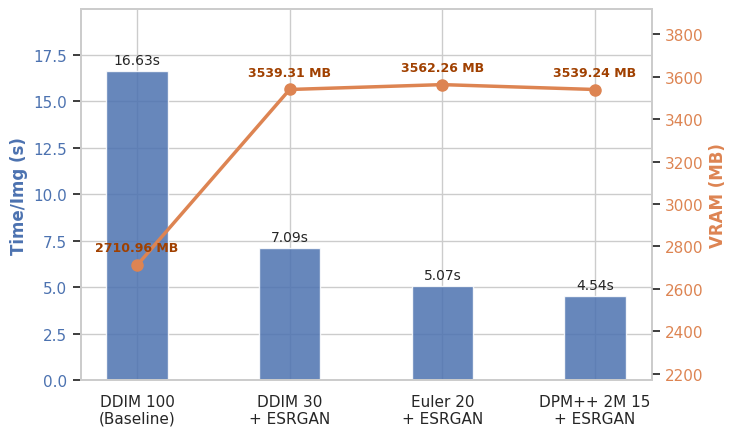

In [ ]:
def plot_speed_vram():
        fig, ax1 = plt.subplots(figsize=(7.5, 4.5))

        color_time = "#4C72B0"
        bars = ax1.bar(models_all, time_img, color=color_time, width=0.4, alpha=0.85, label="Time")
        #ax1.set_xlabel("Cấu hình hệ thống", fontweight="bold", labelpad=10)
        ax1.set_ylabel("Time/Img (s)", color=color_time, fontweight="bold")
        ax1.tick_params(axis="y", labelcolor=color_time)

        # Tự động set trục Y dựa trên giá trị max
        ax1.set_ylim(0, max(time_img) * 1.2)

        for bar in bars:
            height = bar.get_height()
            ax1.annotate(f"{height:.2f}s",
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 3), textcoords="offset points",
                         ha="center", va="bottom", fontsize=10)

        ax2 = ax1.twinx()
        color_vram = "#DD8452"
        ax2.plot(models_all, vram, color=color_vram, marker="o", linewidth=2.5, markersize=8, label="VRAM")
        ax2.set_ylabel("VRAM (MB)", color=color_vram, fontweight="bold")
        ax2.tick_params(axis="y", labelcolor=color_vram)

        ax2.set_ylim(min(vram) * 0.8, max(vram) * 1.1)
        ax2.grid(False)

        for i, txt in enumerate(vram):
            ax2.annotate(f"{txt:.2f} MB", (models_all[i], vram[i]),
                         textcoords="offset points", xytext=(0, 10),
                         ha="center", color="#A04000", fontweight="bold", fontsize=9)

        #plt.title("Biểu đồ so sánh thời gian suy diễn và mức sử dụng VRAM của các phương pháp", fontweight="bold", pad=15)
        plt.tight_layout()
        plt.show()
plot_speed_vram()


2.   Biểu đồ so sánh chất lượng khôi phục ảnh bằng PSNR và SSIM


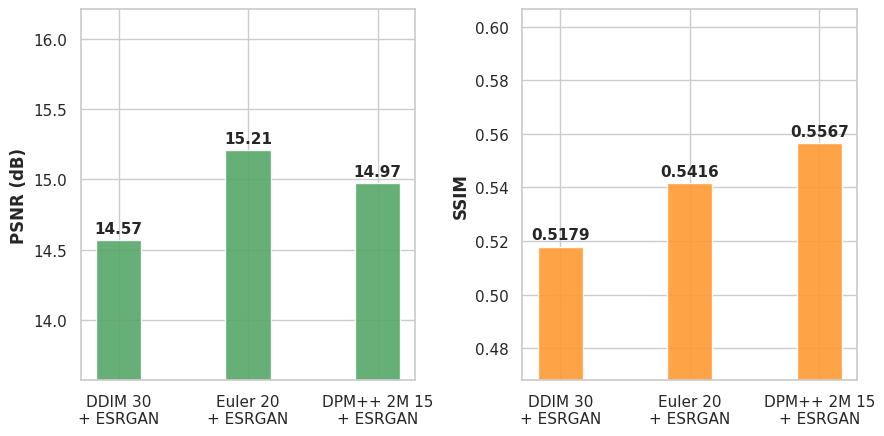

In [ ]:
def plot_fidelity():
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.5))

        # Cột PSNR
        bars1 = ax1.bar(models_prop, psnr, color="#55A868", width=0.35, alpha=0.9)
        ax1.set_ylabel("PSNR (dB)", fontweight="bold")
        ax1.set_ylim(min(psnr) - 1, max(psnr) + 1)
        #ax1.set_title("Chỉ số PSNR (Càng cao càng tốt)", fontsize=11, pad=10)
        for bar in bars1:
            h = bar.get_height()
            ax1.annotate(f"{h:.2f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                         xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontweight="bold")

        # Cột SSIM
        bars2 = ax2.bar(models_prop, ssim, color="#FF9933", width=0.35, alpha=0.9)
        ax2.set_ylabel("SSIM", fontweight="bold")
        ax2.set_ylim(min(ssim) - 0.05, max(ssim) + 0.05)
        #ax2.set_title("Chỉ số SSIM (Càng cao càng tốt)", fontsize=11, pad=10)
        for bar in bars2:
            h = bar.get_height()
            ax2.annotate(f"{h:.4f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                         xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontweight="bold")

        #plt.suptitle("Biểu đồ so sánh chất lượng khôi phục ảnh bằng PSNR và SSIM", fontweight="bold", fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()
plot_fidelity()



3. Biểu đồ thể hiện mối quan hệ giữa thời gian suy diễn và chất lượng ảnh cảm quan (FID)



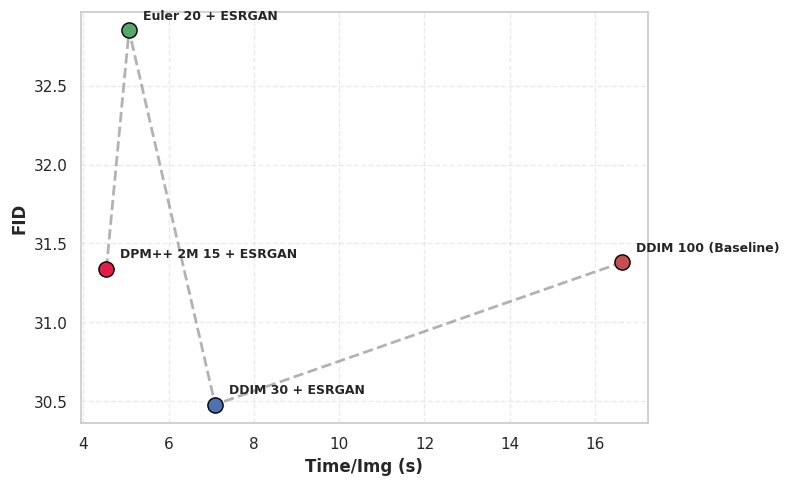

In [ ]:
def plot_speed_vs_fid():

    fig, ax = plt.subplots(figsize=(8, 5))

    colors = ["#C44E52", "#4C72B0", "#55A868", "#E11D48"]

    # Scatter
    for i in range(len(models_all)):

        ax.scatter(
            time_img[i],
            fid[i],
            s=120,
            color=colors[i],
            edgecolor="black",
            linewidth=1,
            zorder=3
        )
        ax.annotate(
            models_all[i].replace("\n", " "),
            (time_img[i], fid[i]),
            textcoords="offset points",
            xytext=(10, 8),
            fontsize=9,
            fontweight="bold"
        )

    # Nối các điểm theo thứ tự thời gian
    sorted_idx = np.argsort(time_img)

    ax.plot(
        np.array(time_img)[sorted_idx],
        np.array(fid)[sorted_idx],
        linestyle="--",
        color="gray",
        alpha=0.6,
        linewidth=2
    )
    ax.set_xlabel(
        "Time/Img (s)",
        fontweight="bold"
    )

    ax.set_ylabel(
        "FID",
        fontweight="bold"
    )

    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

plot_speed_vs_fid()